In [21]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cm

with open('../data/results/2026-07-25_9-55_Keep/combined_trial_data.pkl', 'rb') as f:
    all_trial_data = pickle.load(f)

In [19]:
Stiffness_Sis = []
Error_Sis = []
# Get a list of all the Stiffness Si data
for i, trial in enumerate(all_trial_data):
    Stiffness_Sis.append(trial['stiffness_Si'])
    Error_Sis.append(trial['error_Si'])

morris_problem = all_trial_data[0]['problem']

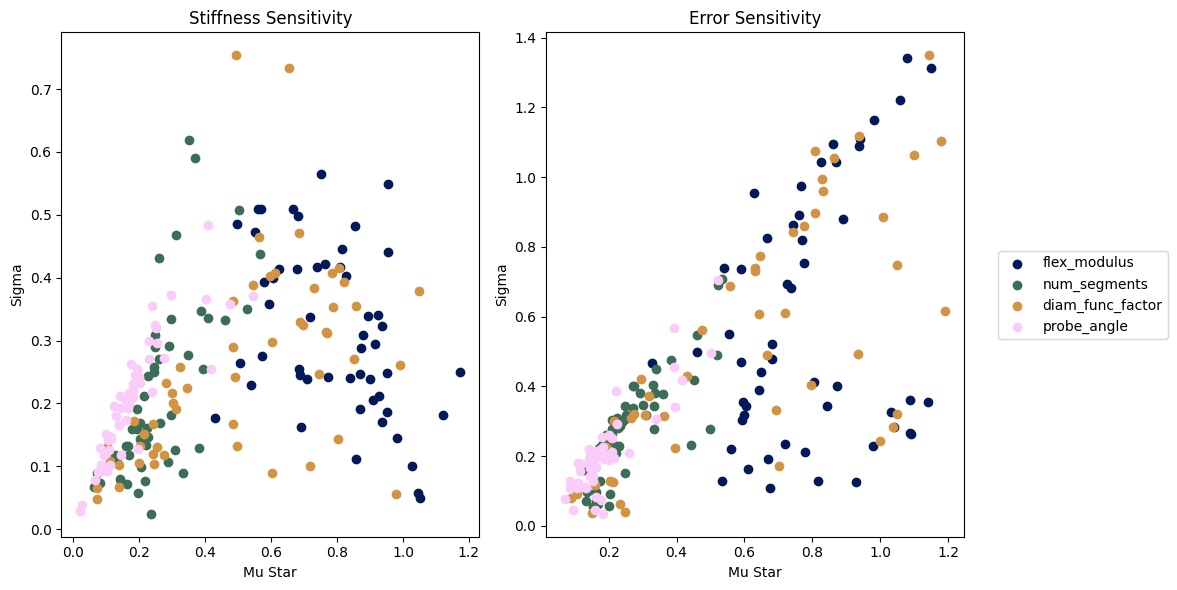

In [22]:

# make a scatterplot with mu star on the x axis and sigma on the y axis for each parameter, for both stiffness and error
# each parameter should be a different color. The stiffness and error will be on different plots. 
plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
colors = [cm.batlow(x) for x in np.linspace(0, 1, len(morris_problem['names']))]
for i, name in enumerate(morris_problem['names']):
    for j in range(len(Stiffness_Sis)):
        ax[0].scatter(Stiffness_Sis[j]['mu_star'][i], Stiffness_Sis[j]['sigma'][i],
                    color=colors[i], label=name if j == 0 else None)
        ax[1].scatter(Error_Sis[j]['mu_star'][i], Error_Sis[j]['sigma'][i],
                    color=colors[i], label=name if j == 0 else None)
ax[0].set_title('Stiffness Sensitivity')
ax[0].set_xlabel('Mu Star')
ax[0].set_ylabel('Sigma')
ax[1].set_title('Error Sensitivity')
ax[1].set_xlabel('Mu Star')
ax[1].set_ylabel('Sigma')
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.83, 0.5))
fig.tight_layout(rect=[0, 0, 0.82, 1])  # leave room on the right for the legend
plt.show()
